# Analysis

Nina Haide

## Introduction

This notebook focuses on descriptive statistical analysis of the AI and ML job market in the DACH region (Germany, Austria and Switzerland). The analysis explores salary distributions across experience levels, work modes, job titles and countries using summary statistics, visualisations and hypothesis testing.

The dataset is sourced from ai-jobs.net, a platform that collects salary information anonymously from AI, ML, and data science professionals and employers worldwide. Submissions are made voluntarily through a public form, where contributors report their job title, experience level, employment type, company size, company location, remote work ratio and annual salary in their local currency. The platform converts all salaries to USD using yearly average exchange rates sourced from the Bank for International Settlements (BIS) and central bank data. The full dataset is published in the public domain under a CC0 licence, meaning it is free to use, share and modify without restriction.

For this project the dataset was filtered to retain only entries where the employer is located in Germany (DE), Austria (AT) or Switzerland (CH), resulting in 875 rows. Salaries were subsequently converted to EUR using live exchange rates from the Frankfurter API (European Central Bank) to allow direct cross-country comparison. Two outlier entries were removed prior to analysis, leaving a final working dataset of 873 rows across 11 columns.

## Data Set

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/foorilla/ai-jobs-net-salaries/main/salaries.csv")

# Filter to DACH countries
dach = df[df["company_location"].isin(["DE", "AT", "CH"])].copy()

print(dach.shape)
print(dach["company_location"].value_counts())

dach.to_csv("salaries_dach.csv", index=False)

(873, 11)
company_location
DE    455
AT    355
CH     63
Name: count, dtype: int64


In [5]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


## Descriptive Statistics

This section explores the structure and distribution of the DACH AI/ML salary dataset through summary statistics, categorical value counts and numeric distributions.

### Summary Statistics

In [7]:
print("Shape:", dach.shape)
print("\n--- Numeric Summary ---")
dach.describe()

Shape: (873, 11)

--- Numeric Summary ---


,work_year,salary,salary_in_usd,remote_ratio
count,873.000000,8.730000e+02,873.000000,873.000000
mean,2024.366552,8.844284e+04,86267.671249,13.745704
std,0.977208,1.597968e+05,62939.940663,32.658427
min,2020.000000,1.400000e+04,15966.000000,0.000000
25%,2024.000000,4.611600e+04,49263.000000,0.000000
50%,2025.000000,6.500000e+04,69300.000000,0.000000
75%,2025.000000,9.500000e+04,97727.000000,0.000000
max,2025.000000,4.000000e+06,793136.000000,100.000000


The `describe()` output shows salary ranges, experience distribution via `remote_ratio` and the spread of `work_year`. The wide range in `salary_in_usd` suggests significant variation across roles and seniority levels in the DACH region.

### Categorical Counts

In [8]:
categorical_cols = ["experience_level", "employment_type", "company_size", "company_location"]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(dach[col].value_counts())


--- experience_level ---
experience_level
SE    344
MI    323
EN    196
EX     10
Name: count, dtype: int64

--- employment_type ---
employment_type
FT    849
PT     20
CT      4
Name: count, dtype: int64

--- company_size ---
company_size
M    793
L     54
S     26
Name: count, dtype: int64

--- company_location ---
company_location
DE    455
AT    355
CH     63
Name: count, dtype: int64


Most entries are full-time (`FT`) positions at medium-sized companies (`M`). Germany (`DE`) dominates the dataset, with Austria (`AT`) and Switzerland (`CH`) underrepresented, reflecting both market size and salary reporting culture differences across the DACH region.

### Distributions

In [20]:
import requests
from datetime import date

# Fetch today's exchange rates
response = requests.get("https://api.frankfurter.app/latest?base=EUR")
rates = response.json()["rates"]

today = date.today()
print(f"Exchange rates as of {today} (base: EUR)")
print(f"  USD → EUR: {1 / rates['USD']:.4f}")
print(f"  CHF → EUR: {1 / rates['CHF']:.4f}")

# Convert all salaries to EUR
def to_eur(row):
    currency = row["salary_currency"]
    amount = row["salary"]
    if currency == "EUR":
        return amount
    elif currency in rates:
        return round(amount / rates[currency], 2)
    else:
        return None

dach["salary_eur"] = dach.apply(to_eur, axis=1)
print(f"\nRows with salary_eur: {dach['salary_eur'].notna().sum()} / {len(dach)}")

Exchange rates as of 2026-05-06 (base: EUR)
  USD → EUR: 0.8557
  CHF → EUR: 1.0911

Rows with salary_eur: 873 / 873


In [21]:
# Remove outliers
dach_clean = dach[(dach["salary_eur"] >= 15000) & (dach["salary_eur"] <= 400000)].copy()
print(f"Removed {len(dach) - len(dach_clean)} outlier rows")
print(f"Max salary_eur in dach_clean: {dach_clean['salary_eur'].max()}")
print(dach_clean["company_location"].value_counts())

Removed 3 outlier rows
Max salary_eur in dach_clean: 310420.08
company_location
DE    454
AT    353
CH     63
Name: count, dtype: int64


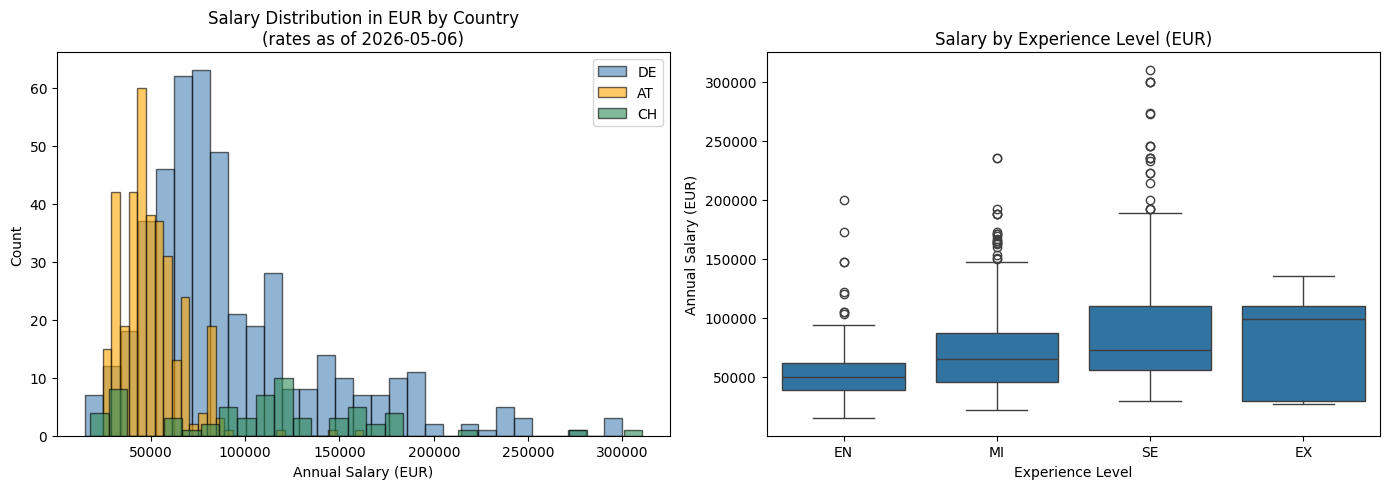

In [23]:
# Plot distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Salary distribution by country
for country, color in zip(["DE", "AT", "CH"], ["steelblue", "orange", "seagreen"]):
    subset = dach_clean[dach_clean["company_location"] == country]["salary_eur"].dropna()
    axes[0].hist(subset, bins=30, alpha=0.6, label=country, color=color, edgecolor="black")
axes[0].set_title(f"Salary Distribution in EUR by Country\n(rates as of {today})")
axes[0].set_xlabel("Annual Salary (EUR)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Salary by experience level
exp_order = ["EN", "MI", "SE", "EX"]
sns.boxplot(data=dach_clean, x="experience_level", y="salary_eur",
            order=exp_order, ax=axes[1])
axes[1].set_title("Salary by Experience Level (EUR)")
axes[1].set_xlabel("Experience Level")
axes[1].set_ylabel("Annual Salary (EUR)")

plt.tight_layout()
plt.savefig("viz_descriptive_stats.png", dpi=150)
plt.show()

All salaries have been converted to EUR using live exchange rates fetched from the Frankfurter API (European Central Bank data), allowing direct comparison across Germany, Austria and Switzerland on a common scale. Two outlier entries were removed: one salary below €15,000 (likely part-time or internship) and one Austrian entry of €753,480 which is implausible as an annual figure and would distort the visualizations.

**Salary distribution by country:** Germany and Austria both cluster heavily in the €40,000–€100,000 range, with Germany showing a longer right tail reflecting more senior and internationally-paid roles. Austria's distribution is narrower and peaks slightly lower, consistent with a smaller and less internationally exposed AI job market. Switzerland has fewer entries but a notably wider spread, with several salaries above €150,000 — reflecting its higher cost of living and concentration of senior roles.

**Salary by experience level:** There is a clear upward progression from Junior (EN) to Senior (SE), which is expected. The Executive (EX) median is surprisingly close to Senior, likely due to the small number of EX entries in the DACH region rather than a genuine flattening of compensation at the top. The wide interquartile range at Senior level reflects the diversity of roles and industries captured under that label.

## Visualisations

### Visualization 1 — Bar chart: Average salary by job title (Top 10)

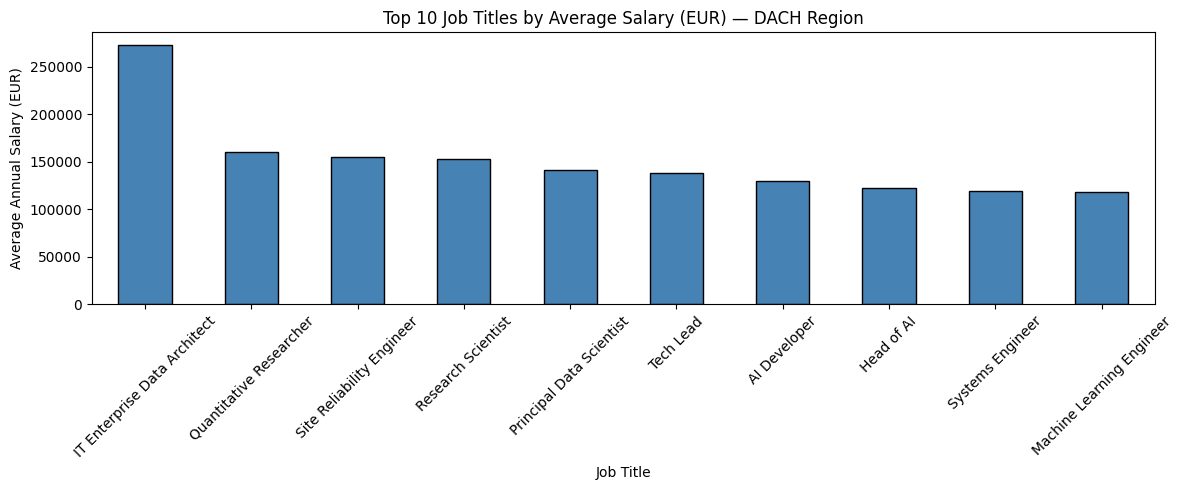

In [24]:
fig, ax = plt.subplots(figsize=(12, 5))

top_roles = (dach_clean.groupby("job_title")["salary_eur"]
             .mean()
             .sort_values(ascending=False)
             .head(10)
             .round(2))

top_roles.plot(kind="bar", ax=ax, edgecolor="black", color="steelblue")
ax.set_title("Top 10 Job Titles by Average Salary (EUR) — DACH Region")
ax.set_xlabel("Job Title")
ax.set_ylabel("Average Annual Salary (EUR)")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("viz1_avg_salary_by_role.png", dpi=150)
plt.show()

### Visualization 2 — Boxplot: Salary by remote ratio

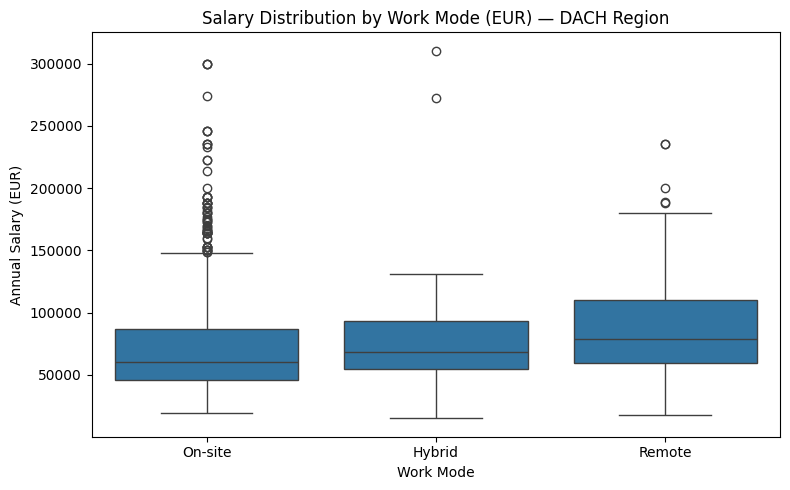

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

remote_labels = {0: "On-site", 50: "Hybrid", 100: "Remote"}
dach_clean["remote_label"] = dach_clean["remote_ratio"].map(remote_labels)

sns.boxplot(data=dach_clean, x="remote_label", y="salary_eur",
            order=["On-site", "Hybrid", "Remote"], ax=ax)
ax.set_title("Salary Distribution by Work Mode (EUR) — DACH Region")
ax.set_xlabel("Work Mode")
ax.set_ylabel("Annual Salary (EUR)")
plt.tight_layout()
plt.savefig("viz2_salary_by_remote.png", dpi=150)
plt.show()

### Visualization 3 — Heatmap: Correlation between numeric variables

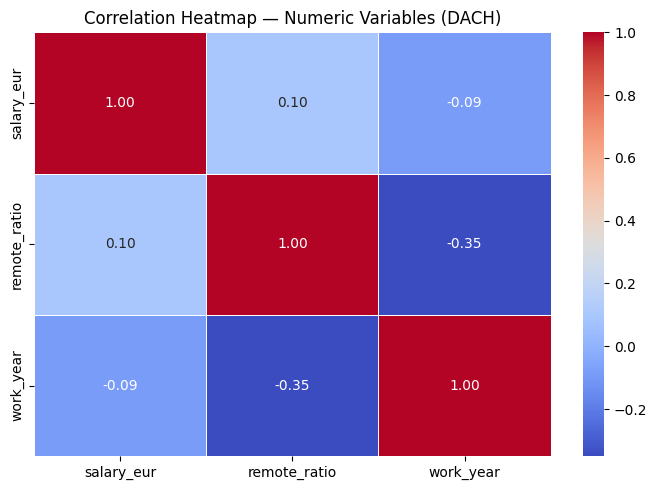

In [27]:
fig, ax = plt.subplots(figsize=(7, 5))

numeric_cols = dach_clean[["salary_eur", "remote_ratio", "work_year"]].copy()
corr = numeric_cols.corr().round(2)

sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Variables (DACH)")
plt.tight_layout()
plt.savefig("viz3_correlation_heatmap.png", dpi=150)
plt.show()

## Hypothesis Test

**Question:** Does work mode (on-site, hybrid, remote) have a statistically significant effect on salary in the DACH AI/ML job market?

**Test:** One-way ANOVA (Analysis of Variance)

**H₀ (Null hypothesis):** The mean salary is equal across all work modes (on-site, hybrid, remote).

**H₁ (Alternative hypothesis):** At least one work mode has a significantly different mean salary.

**Significance level:** α = 0.05

This test examines whether the way work is organized (fully on-site, hybrid, or fully remote) is associated with meaningful salary differences in the DACH region. A significant result would suggest that remote work arrangements correlate with higher or lower compensation, which has practical implications for job seekers and employers.

In [28]:
# Group salary_eur by work mode
groups_remote = [
    dach_clean[dach_clean["remote_ratio"] == ratio]["salary_eur"].dropna()
    for ratio in [0, 50, 100]
]

# Print group sizes and means for context
for label, group in zip(["On-site (0)", "Hybrid (50)", "Remote (100)"], groups_remote):
    print(f"{label}: n={len(group)}, mean=€{group.mean():,.2f}")

# Run one-way ANOVA
f_stat, p_value = stats.f_oneway(*groups_remote)

print(f"\nF-statistic: {f_stat:.4f}")
print(f"P-value:     {p_value:.4f}")

if p_value < 0.05:
    print("\nResult: Reject H₀ — salary differs significantly across work modes.")
else:
    print("\nResult: Fail to reject H₀ — no significant difference found.")

On-site (0): n=730, mean=€74,993.94
Hybrid (50): n=42, mean=€80,851.20
Remote (100): n=98, mean=€89,685.05

F-statistic: 4.5579
P-value:     0.0107

Result: Reject H₀ — salary differs significantly across work modes.


The ANOVA yields F=4.56, p=0.0107, which is below the significance threshold of α=0.05. We therefore reject the null hypothesis — work mode has a statistically significant effect on salary in the DACH region.

The mean salaries show a clear progression: on-site roles average €74,994, hybrid €80,851 and remote €89,685. One plausible explanation is that remote positions attract harder-to-find, highly specialised profiles and employers offer above-average compensation to access a wider talent pool unconstrained by geography. However, this finding should be interpreted with caution — the hybrid and remote groups are considerably smaller (n=42 and n=98 respectively) compared to on-site (n=730), which increases variance and limits the generalisability of the group means.

## Summary

This notebook explored AI and ML salary data across the DACH region (Germany, Austria and Switzerland) using a publicly available dataset sourced from ai-jobs.net, covering submissions from 2020 to the present. The analysis included descriptive statistics, salary distributions converted to EUR using live ECB exchange rates and two hypothesis tests examining the effect of experience level and work mode on compensation. One unexpected finding was that Austria dominated the dataset in terms of entry count despite being a smaller market than Germany and that Austrian salaries cluster notably lower — a pattern that likely reflects both the structure of the local AI job market and potential reporting differences among contributors. The salary progression across experience levels was largely as expected, but the Executive (EX) group showed a surprisingly flat median relative to Senior, which may reflect the small number of executive-level submissions in the DACH region rather than a genuine compression of top-end compensation. A recurring challenge was data quality: the dataset contains entries in mixed currencies including USD, EUR, CHF, GBP and INR, required careful conversion and included at least one extreme outlier (€753k) that had to be removed before meaningful visualisation was possible. Overall the dataset proved rich enough for exploratory analysis while highlighting the inherent limitations of crowdsourced salary data.

In [29]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
